In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from python.animation import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
t1_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t1.slp'
t1_labels = sleap.load_file(t1_labels_path)
t1_all_tracked_points = get_all_tracked_points(t1_labels, reorder=True)
t1_all_tracked_points.shape

all_tracked_points shape: (90002, 17, 2)
Missing point count: 92785
reorder_idx.shape: (17,)


(90002, 17, 2)

In [12]:
t1_labels

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=18)

In [11]:
# c3_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/predictions/c3_predictions.slp.250120_125305.predictions.slp'
# c3_labels = sleap.load_file(c3_labels_path)
# t1_all_tracked_points = get_all_tracked_points(c3_labels, reorder=True)

In [3]:
t1_all_tracked_points.shape

(827, 16, 2)

1. Find swapped IDs: when expanded (radius max), a point should be connected to its 2 closest neighbors; if not, considered as swapped
- ID the center 
- compute the radius for each point 
- if all point radius at least 50% max, ID as expanded

2. Correct (swap)

3. Propagate in time in both directions

## Identify frames where the jellyfish is expanded

### get center position

In [3]:
frame1 = t1_labels.video.get_frame(1)

In [4]:
center_pos = np.array([91, 77])

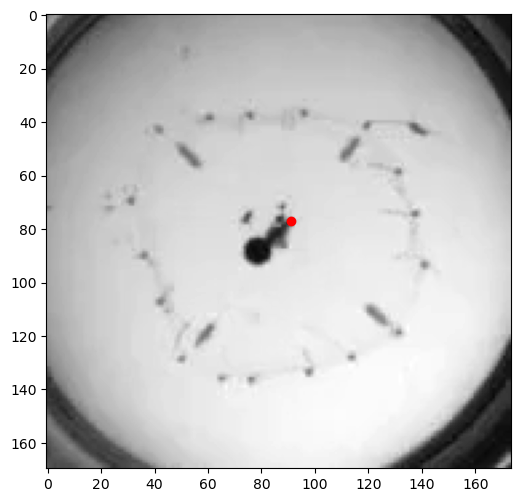

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(frame1[:,:,0], cmap='gray')
plt.plot(center_pos[0], center_pos[1], 'ro')
plt.show()

### get radii for each point 

In [6]:
all_radii = np.zeros(t1_all_tracked_points.shape[:2])
for i in range(t1_all_tracked_points.shape[0]):
    for j in range(t1_all_tracked_points.shape[1]):
        all_radii[i, j] = np.linalg.norm(t1_all_tracked_points[i, j] - center_pos)

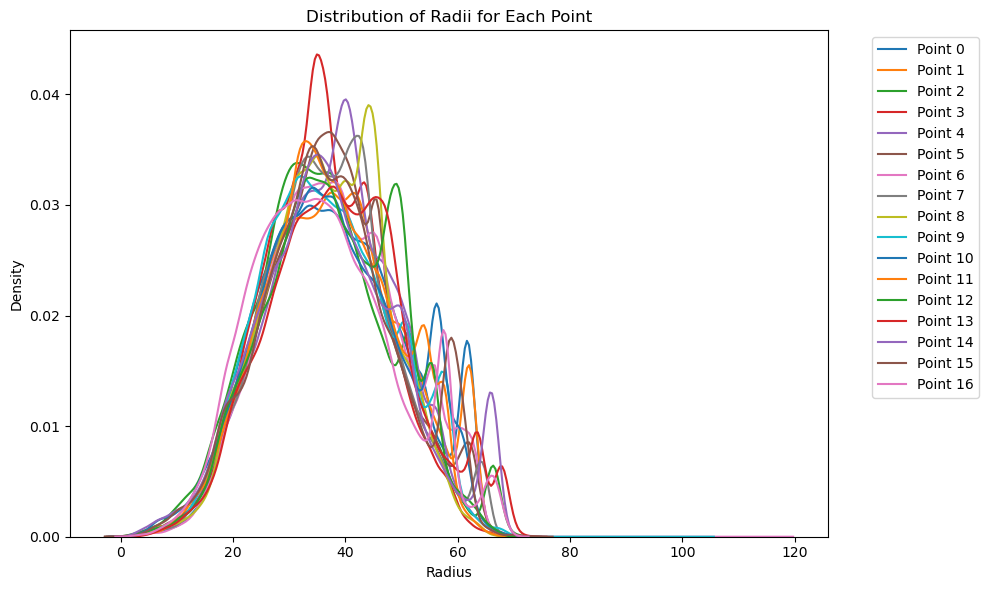

In [7]:
plt.figure(figsize=(10, 6))

# Plot KDE for each point
for i in range(all_radii.shape[1]):
    sns.kdeplot(data=all_radii[:, i], label=f'Point {i}')

plt.xlabel('Radius')
plt.ylabel('Density')
plt.title('Distribution of Radii for Each Point')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

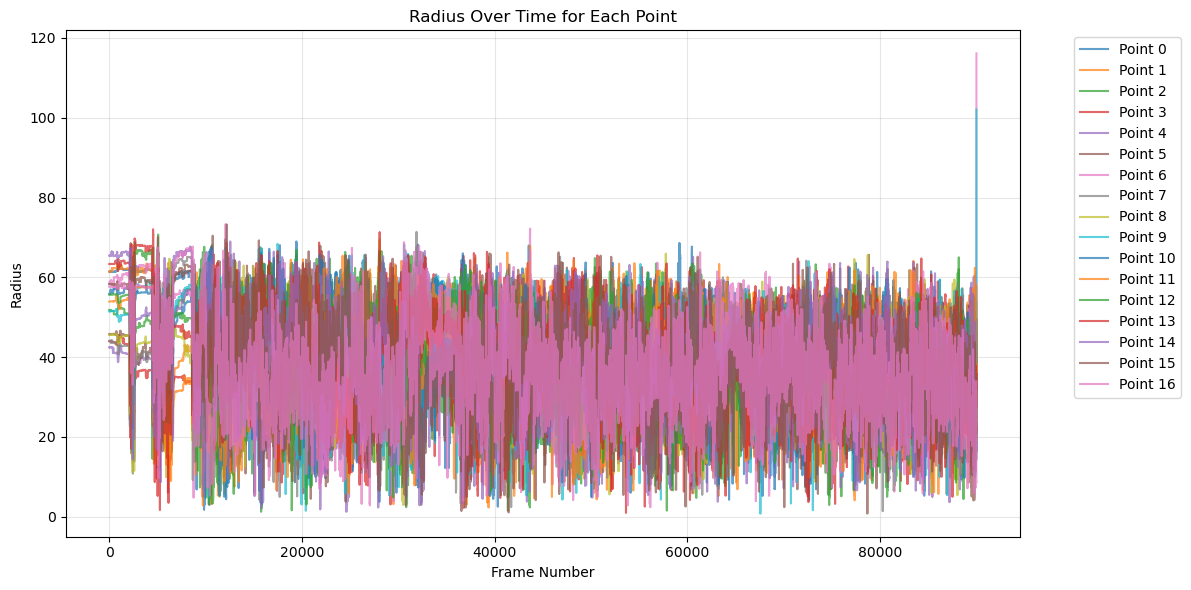

In [8]:
plt.figure(figsize=(12, 6))

# Plot time series for each point
for i in range(all_radii.shape[1]):
    plt.plot(range(all_radii.shape[0]), all_radii[:, i], label=f'Point {i}', alpha=0.7)

plt.xlabel('Frame Number')
plt.ylabel('Radius')
plt.title('Radius Over Time for Each Point')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()